# 03 — TensorFlow model training

How the detection and classification models were trained, and what the training
curves show. Curves are read from the TensorBoard event files written during the
Kaggle GPU run (`logs/detection/` and `logs/classification/`).

## Training strategy

Both models use the same two-phase transfer-learning schedule:

| Phase | Epochs | Backbone | LR | Purpose |
|---|---|---|---|---|
| Warmup | 5 | frozen | 1e-3 | Train the new head without disturbing pretrained features |
| Fine-tune | up to 32 / 64 | unfrozen | 1e-4 | Adapt the backbone to MRI |

Freezing first matters: a randomly initialised head produces large gradients, and
letting those flow into pretrained weights on the first step would destroy the
ImageNet features the transfer is meant to exploit.

**Callbacks** — `EarlyStopping` (restores best weights), `ModelCheckpoint`
(best only), `ReduceLROnPlateau` (halve LR after 4 stagnant epochs),
`TensorBoard`. Detection monitors `val_recall` because a missed tumour is the
costly error; classification monitors `val_accuracy`.

In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


def read_run(task: str, split: str) -> pd.DataFrame:
    """Scalars from the most recent event file for one task/split.

    Newest-first because logs/ can accumulate files from earlier runs, and mixing
    two runs into one curve would be misleading.
    """
    directory = Path("logs") / task / split
    if not directory.exists():
        return pd.DataFrame()
    events = sorted(directory.glob("events.out.tfevents.*"),
                    key=lambda p: p.stat().st_mtime, reverse=True)
    if not events:
        return pd.DataFrame()

    # Keras 3 writes metrics as tensor summaries, not scalar summaries, so
    # accumulator.Scalars() finds nothing and Tensors() has to be used instead.
    accumulator = EventAccumulator(str(events[0]), size_guidance={"tensors": 0})
    accumulator.Reload()

    series = {}
    for tag in accumulator.Tags()["tensors"]:
        # Skip the "keras" tag (the serialised model config, a string) and the
        # duplicated evaluation_*_vs_iterations views of the same numbers.
        if not tag.startswith("epoch_"):
            continue
        points = accumulator.Tensors(tag)
        try:
            series[tag] = pd.Series(
                {p.step: float(tf.make_ndarray(p.tensor_proto)) for p in points}
            )
        except (ValueError, TypeError):
            continue

    frame = pd.DataFrame(series)
    frame.index.name = "epoch"
    return frame


runs = {task: {split: read_run(task, split) for split in ("train", "validation")}
        for task in ("detection", "classification")}

for task, splits in runs.items():
    for split, frame in splits.items():
        print(f"{task:15s} {split:11s} {frame.shape[0]:3d} epochs, "
              f"metrics: {list(frame.columns)}")

detection       train        14 epochs, metrics: ['epoch_accuracy', 'epoch_auc', 'epoch_loss', 'epoch_recall', 'epoch_learning_rate']
detection       validation   14 epochs, metrics: ['epoch_accuracy', 'epoch_auc', 'epoch_loss', 'epoch_recall']
classification  train        23 epochs, metrics: ['epoch_accuracy', 'epoch_loss', 'epoch_top2_accuracy', 'epoch_learning_rate']
classification  validation   23 epochs, metrics: ['epoch_accuracy', 'epoch_loss', 'epoch_top2_accuracy']


## Detection — training curves

**These curves cover the fine-tuning phase only.** The `TensorBoard` callback is
attached to the second `model.fit()` call, so the 5 warmup epochs are not logged;
epoch 0 here is the first epoch after the backbone was unfrozen.

The run length is itself informative: fine-tuning was allowed up to 32 epochs but
stopped at 14, so `EarlyStopping` fired and `restore_best_weights` rolled the
model back to its best `val_recall` epoch.

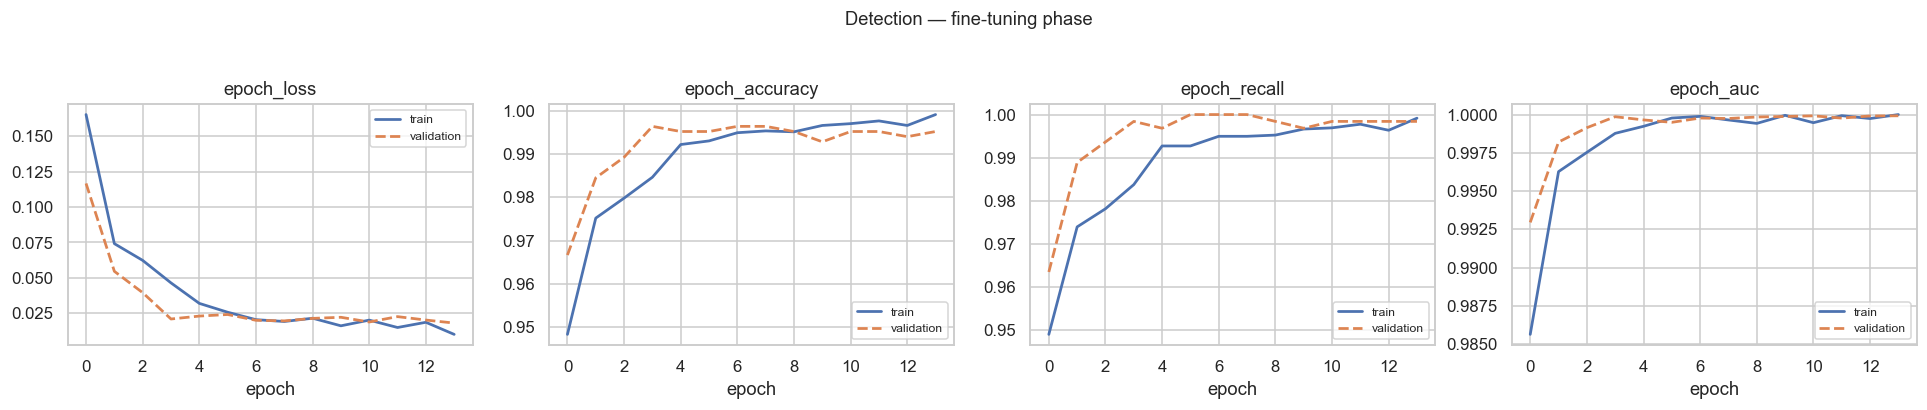

In [2]:
def plot_task(task: str, metrics: list[str], title: str):
    train, validation = runs[task]["train"], runs[task]["validation"]
    available = [m for m in metrics if m in train.columns or m in validation.columns]
    if not available:
        print(f"no scalars found for {task}")
        return

    fig, axes = plt.subplots(1, len(available), figsize=(4.4 * len(available), 3.6))
    axes = [axes] if len(available) == 1 else list(axes)

    for ax, metric in zip(axes, available):
        if metric in train.columns:
            ax.plot(train.index, train[metric], label="train", lw=1.8)
        if metric in validation.columns:
            ax.plot(validation.index, validation[metric], label="validation",
                    lw=1.8, ls="--")
        ax.set_title(metric)
        ax.set_xlabel("epoch")
        ax.legend(fontsize=8)

    fig.suptitle(title, y=1.03, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_task("detection", ["epoch_loss", "epoch_accuracy", "epoch_recall", "epoch_auc"],
          "Detection — fine-tuning phase")

In [3]:
detection_validation = runs["detection"]["validation"]
if not detection_validation.empty:
    summary = pd.DataFrame({
        "best": detection_validation.max(),
        "final": detection_validation.iloc[-1],
        "best epoch": detection_validation.idxmax(),
    })
    display(summary.style.format({"best": "{:.4f}", "final": "{:.4f}"}))

,best,final,best epoch
epoch_accuracy,0.9964,0.9952,3
epoch_auc,0.9999,0.9999,13
epoch_loss,0.1167,0.0181,0
epoch_recall,1.0000,0.9984,5


## Classification — training curves

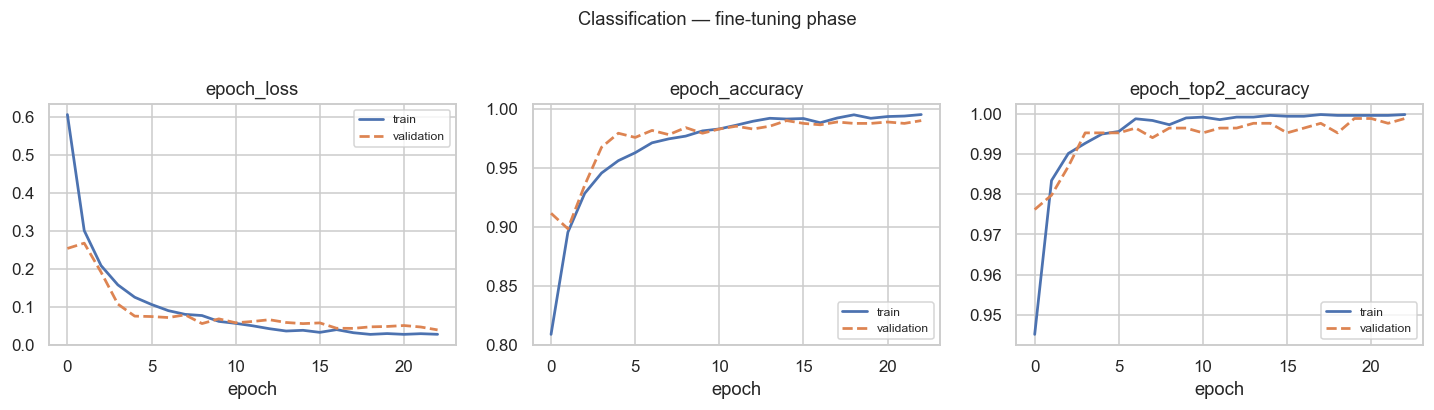

In [4]:
plot_task("classification", ["epoch_loss", "epoch_accuracy", "epoch_top2_accuracy"],
           "Classification — fine-tuning phase")

In [5]:
classification_validation = runs["classification"]["validation"]
if not classification_validation.empty:
    summary = pd.DataFrame({
        "best": classification_validation.max(),
        "final": classification_validation.iloc[-1],
        "best epoch": classification_validation.idxmax(),
    })
    display(summary.style.format({"best": "{:.4f}", "final": "{:.4f}"}))

,best,final,best epoch
epoch_accuracy,0.9905,0.9905,14
epoch_loss,0.2673,0.0392,1
epoch_top2_accuracy,0.9988,0.9988,19


## Overfitting check

The gap between the training and validation curves is the thing to watch. A
training accuracy that keeps climbing while validation flattens or declines means
the model is memorising rather than generalising.

Mitigations already in the architecture and schedule:

- `Dropout(0.4)` then `Dropout(0.2)` in the classifier head
- L2 regularisation (`1e-5`) on the dense layer, plus `BatchNormalization`
- Augmentation — flips, 90-degree rotations, brightness and contrast jitter
- `EarlyStopping(restore_best_weights=True)`, so the returned weights are from
  the best validation epoch rather than the last one

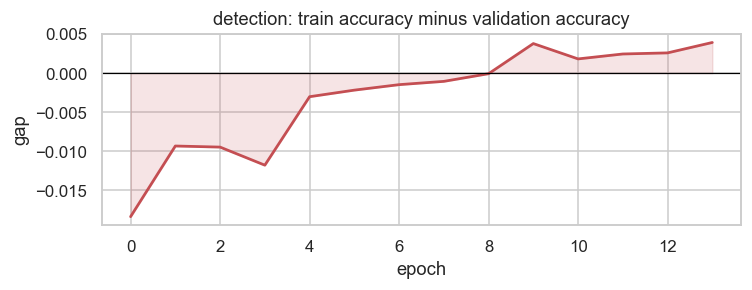

detection: final gap +0.0039, max +0.0039


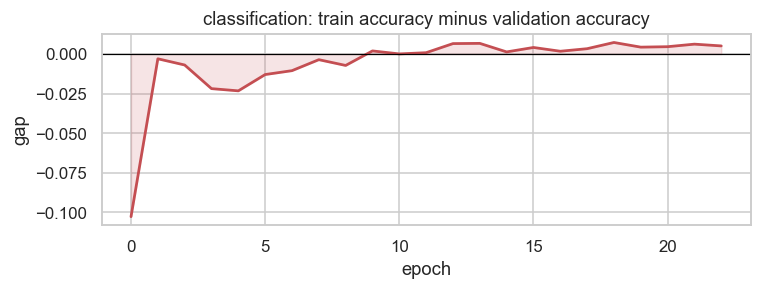

classification: final gap +0.0051, max +0.0073


In [6]:
for task in ("detection", "classification"):
    train, validation = runs[task]["train"], runs[task]["validation"]
    if train.empty or validation.empty or "epoch_accuracy" not in train.columns:
        continue
    shared = train.index.intersection(validation.index)
    gap = train.loc[shared, "epoch_accuracy"] - validation.loc[shared, "epoch_accuracy"]

    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.plot(shared, gap, color="#C44E52", lw=1.8)
    ax.axhline(0, color="black", lw=0.8)
    ax.fill_between(shared, 0, gap, alpha=0.15, color="#C44E52")
    ax.set_title(f"{task}: train accuracy minus validation accuracy")
    ax.set_xlabel("epoch"); ax.set_ylabel("gap")
    plt.tight_layout()
    plt.show()

    print(f"{task}: final gap {gap.iloc[-1]:+.4f}, max {gap.max():+.4f}")

## Learning rate schedule

`ReduceLROnPlateau` halves the learning rate whenever validation loss stops
improving for 4 epochs. Steps down in this curve mark the points where progress
stalled.

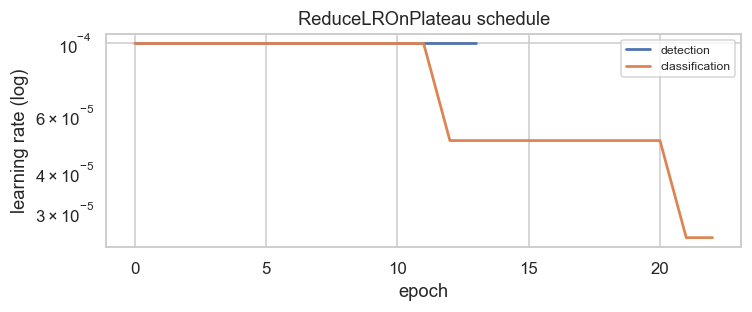

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
plotted = False
for task in ("detection", "classification"):
    train = runs[task]["train"]
    for tag in ("epoch_learning_rate", "learning_rate"):
        if tag in train.columns:
            ax.plot(train.index, train[tag], label=task, lw=1.8)
            plotted = True
            break

if plotted:
    ax.set_yscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel("learning rate (log)")
    ax.set_title("ReduceLROnPlateau schedule")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("learning rate was not logged as a scalar in these runs")
    plt.close()

## Segmentation training

The PyTorch U-Net does not write TensorBoard events — `train_torch_segmentation.py`
prints per-epoch loss and Dice to stdout, which the Kaggle notebook captures in
its cell output rather than to a log file.

It uses a different schedule from the TensorFlow models:

| | Detection / classification | Segmentation |
|---|---|---|
| Loss | binary / sparse categorical cross-entropy | 0.6 x Dice + 0.4 x BCE |
| Scheduler | ReduceLROnPlateau | CosineAnnealingLR |
| Sampling | `class_weight` | `WeightedRandomSampler` |
| Early stopping | val_recall / val_accuracy | val_loss |

The combined loss exists because tumour pixels are a small fraction of the image.
Pure BCE would be minimised well by predicting "background" everywhere; the Dice
term is scale-invariant with respect to region size and prevents that collapse,
while BCE keeps a dense per-pixel gradient.

To get curves here in a future run, add a CSV logger to the epoch loop in
`src/training/train_torch_segmentation.py`.

## Summary

- Two-phase transfer learning: frozen warmup, then full fine-tuning at a lower LR.
- Detection early-stops on `val_recall`, classification on `val_accuracy`.
- `restore_best_weights=True` means the saved model is the best validation epoch,
  not the final one.
- On a Kaggle T4 an epoch took about 6 seconds at 42 ms/step over 149 steps. The
  same workload ran at 13-16 s/step on CPU locally — roughly 300x slower, which is
  why training moved to Kaggle.

Test-set results are in notebook 04.